# Figure generation form 2022 MSRP poster

Make figures for Cruse-Mulhall poster. These plots show preliminary results that a novel DNN architecture can be trained to use information contained in an auditory cue of a target talker to attend to that talker's voice in an auditory mixtures, measured by the network's ability to report a keyword spoken by the target talker. 

For interpretability, we are using the model that applies layer normalization to cochleagram inputs and constrains the slopes of the sigmoid functions with our attentional gain blocks to be positive.  


## Includes the following:
* Word recognition as a function of SNR with two-talker mixtures
* Proportion of trials where model reports background talker's word as a function of SNR
* Word recognition as a function of SNR with single-talker in noise mixtures
* Distribution of attentional gain parameters and values across network depth

___

### Get Packages

In [1]:
import pickle
import numpy as np 

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from pathlib import Path
import pandas as pd

### Define Helper Functions

In [2]:
# Get pandas df from csv of results for each model and each test  

def get_df_from_dir(model_paths, talker=False):
    csv_str = 'metrics.csv'
    #models = [attn_models[0], ctrl_models[0]]
    bad_files = []
    dfs = []
    for model in model_paths:
        # get test csvs
        results_csvs = model.rglob("*.csv")

        for csv in results_csvs:
            try:
                df = pd.read_csv(csv)
                df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
                test_parts = str(model).split("/")[-1].split("_")
                #print(test_parts)
                if talker:
                    df['model'] = test_parts[2]
                    df['snr_condition'] = test_parts[3]
                    df['n_talkers'] = test_parts[0]
                else:
                    df['model'] = test_parts[0]
            #       print(test_parts)
                    df['snr_condition'] = test_parts[1]

                if len(df.filter(regex='acc_step').columns) != 0:
                    df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
                    df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

                dfs.append(df)
            except Exception as e:
                print(e)
                bad_files.append((csv.as_posix(), e))

    results = pd.concat(dfs, axis=0, ignore_index=True)

    # results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
    # results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
    # results.drop('epoch', axis=1, inplace=True)
    if talker:
        version_maxes = results.groupby(['model', 'snr_condition', 'n_talkers']).version.transform(max)
    else:
        version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
    results = results[results.version == version_maxes]
    return results, bad_files 

## Make Figure with model performance

In [3]:
list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/').glob("*"))

[PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/.ipynb_checkpoints'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_pos_slope_bs_64_lr_1e-4')]

In [4]:
bg_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise').glob("*"))
snr_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges').glob("*"))

bg_results, _ = get_df_from_dir(bg_models)
snr_results, _ = get_df_from_dir(snr_models)





No columns to parse from file
No columns to parse from file


In [5]:
bg_results.model.unique()

array(['AttnCNNConstrained', 'AttnCNNOnlyNorm', 'AttnCNNPosSlope',
       'AttnCNN', 'AttnTrackingControl'], dtype=object)

In [6]:

snr_plot = snr_results[snr_results.model.str.contains('AttnCNNConstrained|AttnTrackingControl')]
bg_plot = bg_results[bg_results.model.str.contains('AttnCNNConstrained|AttnTrackingControl')]

In [7]:

bg_plot['model'].replace('AttnCNNConstrained','cued model',inplace=True)
bg_plot['model'].replace('AttnTrackingControl','control model',inplace=True)

snr_plot['model'].replace('AttnCNNConstrained','cued model',inplace=True)
snr_plot['model'].replace('AttnTrackingControl','control model',inplace=True)



/tmp/ipykernel_32420/3454041942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg_plot['model'].replace('AttnCNNConstrained','cued model',inplace=True)
/tmp/ipykernel_32420/3454041942.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg_plot['model'].replace('AttnTrackingControl','control model',inplace=True)
/tmp/ipykernel_32420/3454041942.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snr_plot['model'].replace('AttnCNNCon

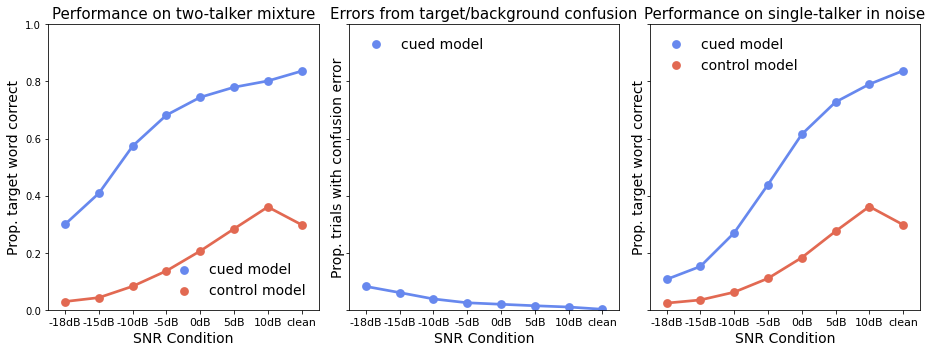

In [13]:
snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

# set single-model plots to match palette 
model_paletts = {'cued model': sns.color_palette("coolwarm", as_cmap=False)[0],
                 'control model': sns.color_palette("coolwarm", as_cmap=False)[-1]
}

fig, axs = plt.subplots(1,3, sharey=True, figsize=(13,5))
axs = axs.ravel()

# hue_order = ['cued model', "control model"]
snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sns.pointplot(
    data=snr_plot, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[0],
    palette=model_paletts, order=snr_order
)


g1 = sns.pointplot(
    data=snr_plot[snr_plot.model != 'control model'],
    x='snr_condition',y='fg_confusion',
    hue='model',# hue_order=['cued model'],
    ci=95, seed=1, ax=axs[1],
    palette=model_paletts, order=snr_order
)


g2 = sns.pointplot(
    data=bg_plot, x='snr_condition', y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[2],
    palette=model_paletts, order=snr_order
)

axs[0].set_title("Performance on two-talker mixture", fontsize=15)
axs[1].set_title("Errors from target/background confusion", fontsize=15)
axs[2].set_title("Performance on single-talker in noise", fontsize=15)


axs[0].set_ylabel("Prop. target word correct", fontsize=14)
axs[1].set_ylabel("Prop. trials with confusion error", fontsize=14)
axs[2].set_ylabel("Prop. target word correct", fontsize=14)

axs[0].set_xlabel("SNR Condition", fontsize=14)
axs[1].set_xlabel("SNR Condition", fontsize=14)
axs[2].set_xlabel("SNR Condition", fontsize=14)

axs[0].tick_params(axis='x', labelsize=11)
axs[1].tick_params(axis='x', labelsize=11)
axs[2].tick_params(axis='x', labelsize=11)

axs[0].set_ylim((0,1))
axs[1].set_ylim((0,1))
axs[2].set_ylim((0,1))


axs[0].legend(title='', loc='lower right', frameon=False, fontsize=14)
axs[1].legend(title='', loc='upper left', frameon=False, fontsize=14)
axs[2].legend(title='', frameon=False, fontsize=14)


plt.tight_layout()





## Make Figure of Attentional Gain Parameters

### Get Saved Activations & Params

only want the constrained slope with layer norm model

In [ ]:
model_path = '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attentional_gain_activations/' \
        'attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4.pkl'

with open(model_path, 'rb') as f:
    acts = pickle.load(f)

### Make DF for easy plotting

In [ ]:

model_dfs = []
for layer in acts['cue_acts'].keys():
    layer_dict = {'cue_acts': acts['cue_acts'][layer],
                'gain_acts': acts['gain_acts'][layer],
                'layer':[f"{layer}"] * len(acts['cue_acts'][layer])}
#                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
    layer_df = pd.DataFrame.from_dict(layer_dict)
    model_dfs.append(layer_df)
model_df = pd.concat(model_dfs)


In [ ]:
# act_df = pd.concat(dfs).reset_index()
model_df

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def attn_gain(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)
    

In [ ]:
def get_sigmoid(acts, layer, n_bins):
    gain_fn_params = acts['gain_params'][layer]
    cue_acts = acts['cue_acts'][layer]
    
    x_for_fn = np.linspace(cue_acts.min(), cue_acts.max(), n_bins)
    bias = gain_fn_params['bias']
    slope = gain_fn_params['slope']
    threshold = gain_fn_params['threshold']
    
    return attn_gain(x_for_fn, bias, slope, threshold).T, x_for_fn
    
        

In [ ]:
# sigmoids

In [ ]:

# Look at inputs to gain functions 
fig, axs = plt.subplots(2,3, figsize=(12,6))
# axs = axs.ravel()

n_hist_bins = 100
pad = 8

c_palette = sns.color_palette("rocket_r", 9, as_cmap=False)
layer_palette = { 0: c_palette[0],
                 1: c_palette[7]
}
print(layer_palette)

layer_names = model_df.layer.unique()
layer_names_sp = [layer_names[0], layer_names[-1]]

# x_for_sigmoid = np.arange(n_hist_bins)

for ix, layer in enumerate(layer_names_sp):

    # Plot filters 
    
    gain_filter, input_act_vals = get_sigmoid(acts, layer, n_hist_bins)    
    axs[ix,0].plot(input_act_vals, gain_filter, linewidth=2, c=layer_palette[ix]) # linewidth=4,

    # plot hist of cue activations    
    sns.histplot(data=model_df[model_df.layer == layer], x='cue_acts',
             stat='percent',  log_scale=(False, True), edgecolor='0.1',
#              hue='model', hue_order=hue_order, palette=model_palette,
             color=layer_palette[ix], bins=n_hist_bins, ax=axs[ix,1])

    # plot hist of gains
    sns.histplot(data=model_df[model_df.layer == layer], x='gain_acts',
                 stat='percent',  log_scale=(False, True), edgecolor='0.1',
#                  hue='model', hue_order=hue_order, palette=model_palette,
                 color=layer_palette[ix], bins=n_hist_bins, ax=axs[ix,2])
    
#     axs[ix,0].annotate(layer, xy=(0, 0.5), xytext=(-axs[ix,0].yaxis.labelpad - pad, 0),
#                 xycoords=axs[ix,0].yaxis.label, textcoords='offset points',
#                 size='large', ha='right', va='center')
    
    
    axs[ix,0].set_ylabel("Gain", fontsize=15)
    axs[ix,0].set_xlabel("Relative activation magnitude", fontsize=15)
    axs[ix,0].set_ylim(0,1.1)

    axs[ix,1].set_xlabel("Activation magnitude", fontsize=15)
    axs[ix,2].set_xlabel("Gain", fontsize=15)
    
axs[0,0].set_title("Gain over range of pre-gain activations", fontsize=16)
axs[0,1].set_title("Cue activations pre-gain", fontsize=16)
axs[0,2].set_title("Gain activations", fontsize=16)



# axs[0,0].legend(loc="upper right", bbox_to_anchor=(4.25, 1))
# axs[0,1].get_legend().remove()
# axs[0,2].get_legend().remove()

# for ax in axs[1:,1:].ravel():
#     ax.get_legend().remove()
        

# plt.suptitle('LayerNorm after Cochleagram - Constrained Slope', y=1)


plt.tight_layout()